# Integrantes:
- Carlo Reyes Espinoza.
- Ignacia Reyes Espinoza.

# Docente:
- Marcelo Tapia Contreras.

# Implementación de Transformers para Procesamiento de Lenguaje Natural (NLP)

**Entregable 3.2 — Modelo Transformer (Encoder-Decoder) para generación de diálogo**

Dataset: DailyDialog

### Objetivo
En esta evaluación implementamos un modelo basado en arquitecturas **Transformer** para una tarea de NLP, utilizando el dataset **DailyDialog**. La tarea elegida es **generación de respuestas de diálogo** (dado un turno de conversación, el modelo genera el siguiente turno).

Construimos un Transformer **encoder-decoder** completo en TensorFlow/Keras, con:
- **Encoder**: procesa el turno de entrada (contexto).
- **Decoder**: genera el turno de salida (respuesta), token por token, usando *self-attention* enmascarada y *cross-attention* sobre la salida del encoder.
- **Atención Multi-cabezal (Multi-Head Attention)**: permite que el modelo atienda a distintas partes de la secuencia simultáneamente, capturando relaciones de largo alcance.

Al final evaluamos el modelo con **BLEU** y **ROUGE-L**, y comparamos distintas configuraciones de hiperparámetros (número de cabezas, capas, dimensión del feed-forward).


In [ ]:
!pip install rouge
!pip install rouge-score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=4cd55ee1e393c1f0e06871a82fa053983f9edc94360600336ccef86618aab4bc
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


## 1. Carga y Exploración del Dataset: DailyDialog


In [ ]:
import re
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import os

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

def extract_utterances(dialog_str):
    pattern = r"'(.*?)'|\"(.*?)\""
    matches = re.findall(pattern, str(dialog_str))
    return [m[0] or m[1] for m in matches if m[0] or m[1]]

rutas = [
    "/content/train.csv",
    "/content/validation.csv",
    "/content/test.csv"
]

dialogos_completos = []

print("Procesando archivos CSV locales...")
for ruta in rutas:
    if os.path.exists(ruta):
        df = pd.read_csv(ruta)
        df['dialog_limpio'] = df['dialog'].apply(extract_utterances)
        dialogos_completos.extend(df['dialog_limpio'].tolist())
    else:
        print(f" Archivo no encontrado: {ruta}")

pairs = []
for dialog in dialogos_completos:
    for i in range(len(dialog) - 1):
        src = dialog[i].strip()
        tgt = dialog[i + 1].strip()
        if len(src) > 0 and len(tgt) > 0:
            pairs.append((src, tgt))

print(f"\n¡Éxito! Total de pares (entrada, respuesta) generados: {len(pairs)}\n")
if len(pairs) > 0:
    for src, tgt in pairs[:3]:
        print("ENTRADA:", src)
        print("RESPUESTA:", tgt)
        print("---")

Procesando archivos CSV locales...

¡Éxito! Total de pares (entrada, respuesta) generados: 89909

ENTRADA: Say , Jim , how about going for a few beers after dinner ?
RESPUESTA: You know that is tempting but is really not good for our fitness .
---
ENTRADA: You know that is tempting but is really not good for our fitness .
RESPUESTA: What do you mean ? It will help us to relax .
---
ENTRADA: What do you mean ? It will help us to relax .
RESPUESTA: Do you really think so ? I don't . It will just make us fat and act silly . Remember last time ?
---


### 1.1 Construcción de pares (contexto → respuesta)

Para la tarea de **generación de texto en diálogo**, transformamos cada diálogo de `n` turnos en `n-1` pares `(entrada, salida)`, donde la entrada es un turno y la salida es el turno inmediatamente siguiente.

In [ ]:
pairs = []
for dialog in dialogos_completos:
    for i in range(len(dialog) - 1):
        src = dialog[i].strip()
        tgt = dialog[i + 1].strip()
        if len(src) > 0 and len(tgt) > 0:
            pairs.append((src, tgt))

print(f"Total de pares (entrada, respuesta): {len(pairs)}\n ")
for src, tgt in pairs[:3]:
    print("ENTRADA:", src)
    print("RESPUESTA:", tgt)
    print("---")


Total de pares (entrada, respuesta): 89909
 
ENTRADA: Say , Jim , how about going for a few beers after dinner ?
RESPUESTA: You know that is tempting but is really not good for our fitness .
---
ENTRADA: You know that is tempting but is really not good for our fitness .
RESPUESTA: What do you mean ? It will help us to relax .
---
ENTRADA: What do you mean ? It will help us to relax .
RESPUESTA: Do you really think so ? I don't . It will just make us fat and act silly . Remember last time ?
---


### 1.2 Limpieza, tokenización y vocabulario

- Pasamos el texto a minúsculas y separamos la puntuación.
- Agregamos los tokens especiales `<start>` y `<end>` a la secuencia de salida (necesarios para que el decoder sepa cuándo empezar y terminar de generar).
- Construimos el vocabulario con `tf.keras.preprocessing.text.Tokenizer`, limitando el tamaño máximo de vocabulario para mantener el modelo liviano.

In [ ]:
import re

def limpiar_texto(texto):
    texto = texto.lower().strip()
    texto = re.sub(r"([?.!,¿])", r" \1 ", texto)
    texto = re.sub(r'[" "]+', " ", texto)
    texto = re.sub(r"[^a-zA-Z?.!,¿']+", " ", texto)
    return texto.strip()

VOCAB_SIZE = 8000
MAX_LEN = 20

entradas_limpias = [limpiar_texto(s) for s, t in pairs]
salidas_limpias = ["<start> " + limpiar_texto(t) + " <end>" for s, t in pairs]

tokenizer = tf.keras.preprocessing.text.Tokenizer(
    num_words=VOCAB_SIZE, oov_token="<oov>", filters=""
)
tokenizer.fit_on_texts(entradas_limpias + salidas_limpias)

VOCAB_SIZE = min(VOCAB_SIZE, len(tokenizer.word_index) + 1)
print("Tamaño real de vocabulario:", VOCAB_SIZE)

seq_in = tokenizer.texts_to_sequences(entradas_limpias)
seq_out = tokenizer.texts_to_sequences(salidas_limpias)

seq_in = tf.keras.preprocessing.sequence.pad_sequences(seq_in, maxlen=MAX_LEN, padding="post", truncating="post")
seq_out = tf.keras.preprocessing.sequence.pad_sequences(seq_out, maxlen=MAX_LEN + 2, padding="post", truncating="post")

print("Forma entradas:", seq_in.shape, "| Forma salidas:", seq_out.shape)


Tamaño real de vocabulario: 8000
Forma entradas: (89909, 20) | Forma salidas: (89909, 22)


### 1.3 División en entrenamiento / validación / prueba y construcción de `tf.data.Dataset`

Para el decoder usamos *teacher forcing*: la entrada del decoder es la secuencia de salida desplazada (sin el último token) y el target es la misma secuencia desplazada un paso a la derecha (sin el primer token, `<start>`).

In [ ]:
from sklearn.model_selection import train_test_split

dec_input = seq_out[:, :-1]
dec_target = seq_out[:, 1:]

X_train_enc, X_temp_enc, X_train_dec, X_temp_dec, y_train, y_temp = train_test_split(
    seq_in, dec_input, dec_target, test_size=0.2, random_state=SEED
)
X_val_enc, X_test_enc, X_val_dec, X_test_dec, y_val, y_test = train_test_split(
    X_temp_enc, X_temp_dec, y_temp, test_size=0.5, random_state=SEED
)

print("Train:", X_train_enc.shape[0], "| Val:", X_val_enc.shape[0], "| Test:", X_test_enc.shape[0])

BATCH_SIZE = 64

def make_dataset(enc_in, dec_in, target, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices(((enc_in, dec_in), target))
    if shuffle:
        ds = ds.shuffle(len(enc_in), seed=SEED)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(X_train_enc, X_train_dec, y_train, shuffle=True)
val_ds = make_dataset(X_val_enc, X_val_dec, y_val, shuffle=False)
test_ds = make_dataset(X_test_enc, X_test_dec, y_test, shuffle=False)


Train: 71927 | Val: 8991 | Test: 8991


## 2. Implementación del Modelo Transformer

Implementamos la arquitectura **encoder-decoder** completa siguiendo el diseño original de *Attention is All You Need* (Vaswani et al., 2017), adaptada con `tf.keras.layers.MultiHeadAttention`.

### Componentes clave

- **Positional Encoding**: como el Transformer no tiene recurrencia ni convoluciones, necesitamos inyectar información sobre la *posición* de cada token en la secuencia. Se usa una combinación de funciones seno/coseno de distintas frecuencias.
- **Encoder**: una pila de `N` capas. Cada capa tiene (1) *self-attention* multi-cabezal sobre la secuencia de entrada y (2) una red feed-forward, ambas con conexiones residuales y normalización.
- **Decoder**: una pila de `N` capas. Cada capa tiene (1) *self-attention* enmascarada (un token solo puede atender a los tokens anteriores, para no "ver el futuro" durante el entrenamiento), (2) *cross-attention*, donde el decoder atiende a la salida del encoder (así conecta la respuesta generada con el contexto de entrada), y (3) una red feed-forward.
- **Máscaras**: máscara de *padding* (para ignorar los tokens de relleno) y máscara *look-ahead* (para el self-attention causal del decoder).

In [ ]:
def positional_encoding(length, depth):
    depth_half = depth / 2
    positions = np.arange(length)[:, np.newaxis]
    depths = np.arange(depth_half)[np.newaxis, :] / depth_half
    angle_rates = 1 / (10000 ** depths)
    angle_rads = positions * angle_rates
    pos_encoding = np.concatenate([np.sin(angle_rads), np.cos(angle_rads)], axis=-1)
    return tf.cast(pos_encoding, dtype=tf.float32)

class PositionalEmbedding(tf.keras.layers.Layer):
    """Embedding de tokens + Positional Encoding sumado."""
    def __init__(self, vocab_size, d_model, max_len=2048, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.embedding = tf.keras.layers.Embedding(vocab_size, d_model, mask_zero=True)
        self.pos_encoding = positional_encoding(max_len, d_model)

    def compute_mask(self, *args, **kwargs):
        return self.embedding.compute_mask(*args, **kwargs)

    def call(self, x):
        length = tf.shape(x)[1]
        x = self.embedding(x)
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        x = x + self.pos_encoding[tf.newaxis, :length, :]
        return x

class EncoderLayer(tf.keras.layers.Layer):
    """Una capa del encoder: self-attention + feed-forward, con residual + layer norm."""
    def __init__(self, d_model, num_heads, dff, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.mha = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=d_model // num_heads, dropout=dropout_rate
        )
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(dff, activation="relu"),
            tf.keras.layers.Dense(d_model),
        ])
        self.norm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout = tf.keras.layers.Dropout(dropout_rate)

    def call(self, x, training=False, padding_mask=None):
        attn_out = self.mha(query=x, value=x, key=x,
                             attention_mask=padding_mask, training=training)
        x = self.norm1(x + attn_out)
        ffn_out = self.dropout(self.ffn(x), training=training)
        x = self.norm2(x + ffn_out)
        return x

class Encoder(tf.keras.layers.Layer):
    def __init__(self, num_layers, d_model, num_heads, dff, vocab_size,
                 max_len=2048, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.pos_embedding = PositionalEmbedding(vocab_size, d_model, max_len)
        self.enc_layers = [EncoderLayer(d_model, num_heads, dff, dropout_rate)
                            for _ in range(num_layers)]
        self.dropout = tf.keras.layers.Dropout(dropout_rate)

    def call(self, x, training=False):
        padding_mask = self.compute_padding_mask(x)
        x = self.pos_embedding(x)
        x = self.dropout(x, training=training)
        for layer in self.enc_layers:
            x = layer(x, training=training, padding_mask=padding_mask)
        return x

    @staticmethod
    def compute_padding_mask(x):
        mask = tf.not_equal(x, 0)
        return mask[:, tf.newaxis, :]

class DecoderLayer(tf.keras.layers.Layer):
    """Una capa del decoder: self-attention causal + cross-attention + feed-forward."""
    def __init__(self, d_model, num_heads, dff, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.self_attn = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=d_model // num_heads, dropout=dropout_rate
        )
        self.cross_attn = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=d_model // num_heads, dropout=dropout_rate
        )
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(dff, activation="relu"),
            tf.keras.layers.Dense(d_model),
        ])
        self.norm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.norm3 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout = tf.keras.layers.Dropout(dropout_rate)

    def call(self, x, enc_output, training=False, causal_mask=None, cross_mask=None):
        attn1 = self.self_attn(query=x, value=x, key=x,
                                attention_mask=causal_mask, use_causal_mask=True,
                                training=training)
        x = self.norm1(x + attn1)

        attn2 = self.cross_attn(query=x, value=enc_output, key=enc_output,
                                 attention_mask=cross_mask, training=training)
        x = self.norm2(x + attn2)

        ffn_out = self.dropout(self.ffn(x), training=training)
        x = self.norm3(x + ffn_out)
        return x

class Decoder(tf.keras.layers.Layer):
    def __init__(self, num_layers, d_model, num_heads, dff, vocab_size,
                 max_len=2048, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.pos_embedding = PositionalEmbedding(vocab_size, d_model, max_len)
        self.dec_layers = [DecoderLayer(d_model, num_heads, dff, dropout_rate)
                            for _ in range(num_layers)]
        self.dropout = tf.keras.layers.Dropout(dropout_rate)

    def call(self, x, enc_output, enc_input, training=False):
        cross_mask = Encoder.compute_padding_mask(enc_input)
        x = self.pos_embedding(x)
        x = self.dropout(x, training=training)
        for layer in self.dec_layers:
            x = layer(x, enc_output, training=training, cross_mask=cross_mask)
        return x

class Transformer(tf.keras.Model):
    """Modelo Transformer encoder-decoder completo para generación de diálogo."""
    def __init__(self, num_layers, d_model, num_heads, dff, vocab_size,
                 max_len=2048, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.encoder = Encoder(num_layers, d_model, num_heads, dff, vocab_size, max_len, dropout_rate)
        self.decoder = Decoder(num_layers, d_model, num_heads, dff, vocab_size, max_len, dropout_rate)
        self.final_layer = tf.keras.layers.Dense(vocab_size)

    def call(self, inputs, training=False):
        enc_input, dec_input = inputs
        enc_output = self.encoder(enc_input, training=training)
        dec_output = self.decoder(dec_input, enc_output, enc_input, training=training)
        logits = self.final_layer(dec_output)
        return logits

### 2.1 Verificación rápida de formas (sanity check)

Antes de entrenar, verificamos que el modelo corre hacia adelante (*forward pass*) sin errores y que las formas de salida son las esperadas: `(batch, longitud_decoder, vocab_size)`.

In [ ]:
D_MODEL = 128
NUM_HEADS = 4
NUM_LAYERS = 2
DFF = 256
DROPOUT = 0.1

modelo_prueba = Transformer(NUM_LAYERS, D_MODEL, NUM_HEADS, DFF, VOCAB_SIZE,
                             max_len=MAX_LEN + 5, dropout_rate=DROPOUT)

for (enc_in_batch, dec_in_batch), target_batch in train_ds.take(1):
    salida = modelo_prueba((enc_in_batch, dec_in_batch), training=False)
    print("Forma entrada encoder:", enc_in_batch.shape)
    print("Forma entrada decoder:", dec_in_batch.shape)
    print("Forma salida (logits):", salida.shape, "-> esperado (batch, dec_len, vocab_size)")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'encoder_layer' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'decoder_layer' (of type DecoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Forma entrada encoder: (64, 20)
Forma entrada decoder: (64, 21)
Forma salida (logits): (64, 21, 8000) -> esperado (batch, dec_len, vocab_size)


## 3. Entrenamiento del Modelo

### Función de pérdida y métrica enmascaradas
Como las secuencias tienen *padding* (relleno con ceros), necesitamos que la pérdida y la métrica de accuracy **ignoren** las posiciones de padding; de otro modo el modelo "aprendería" trivialmente a predecir ceros.

### Hiperparámetros
Los hiperparámetros clave que ajustaremos en la Sección 5 son: **número de cabezas de atención (`num_heads`)**, **número de capas (`num_layers`)**, **dimensión del feed-forward (`dff`)**, **tasa de aprendizaje**, **tamaño del batch** y **número de épocas**.

In [ ]:
def masked_loss(y_true, y_pred):
    mask = tf.cast(tf.math.not_equal(y_true, 0), tf.float32)
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction="none")
    loss = loss_fn(y_true, y_pred)
    loss *= mask
    return tf.reduce_sum(loss) / (tf.reduce_sum(mask) + 1e-8)

def masked_accuracy(y_true, y_pred):
    y_pred_ids = tf.argmax(y_pred, axis=-1)
    y_true = tf.cast(y_true, y_pred_ids.dtype)
    mask = tf.cast(tf.math.not_equal(y_true, 0), tf.float32)
    matches = tf.cast(tf.math.equal(y_true, y_pred_ids), tf.float32) * mask
    return tf.reduce_sum(matches) / (tf.reduce_sum(mask) + 1e-8)

class CustomSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    """Learning rate schedule del paper original: warmup lineal + decaimiento."""
    def __init__(self, d_model, warmup_steps=2000):
        super().__init__()
        self.d_model = tf.cast(d_model, tf.float32)
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        arg1 = tf.math.rsqrt(step)
        arg2 = step * (self.warmup_steps ** -1.5)
        return tf.math.rsqrt(self.d_model) * tf.math.minimum(arg1, arg2)

    def get_config(self):
        return {"d_model": float(self.d_model.numpy()), "warmup_steps": self.warmup_steps}


In [ ]:
def construir_y_compilar_modelo(num_layers, d_model, num_heads, dff,
                                  dropout_rate=0.1, learning_rate=None):
    modelo = Transformer(num_layers, d_model, num_heads, dff, VOCAB_SIZE,
                          max_len=MAX_LEN + 5, dropout_rate=dropout_rate)
    if learning_rate is None:
        lr_schedule = CustomSchedule(d_model)
        optimizer = tf.keras.optimizers.Adam(lr_schedule, beta_1=0.9, beta_2=0.98, epsilon=1e-9)
    else:
        optimizer = tf.keras.optimizers.Adam(learning_rate)
    modelo.compile(optimizer=optimizer, loss=masked_loss, metrics=[masked_accuracy])
    return modelo

batch_size = 64
epochs = 10
learning_rate = 0.001

modelo = construir_y_compilar_modelo(
    num_layers=NUM_LAYERS, d_model=D_MODEL, num_heads=NUM_HEADS, dff=DFF,
    dropout_rate=DROPOUT, learning_rate=learning_rate

)


In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

historia = modelo.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=[early_stop],
)


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'encoder_layer_2' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'decoder_layer_2' (of type DecoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


1124/1124 ━━━━━━━━━━━━━━━━━━━━ 77s 35ms/step - loss: 4.3577 - masked_accuracy: 0.2633 - val_loss: 3.8938 - val_masked_accuracy: 0.3007
Epoch 2/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - loss: 3.7561 - masked_accuracy: 0.3078 - val_loss: 3.6822 - val_masked_accuracy: 0.3187
Epoch 3/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - loss: 3.5153 - masked_accuracy: 0.3254 - val_loss: 3.5715 - val_masked_accuracy: 0.3288
Epoch 4/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - loss: 3.3424 - masked_accuracy: 0.3382 - val_loss: 3.5153 - val_masked_accuracy: 0.3341
Epoch 5/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - loss: 3.2068 - masked_accuracy: 0.3505 - val_loss: 3.4718 - val_masked_accuracy: 0.3406
Epoch 6/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - loss: 3.0932 - masked_accuracy: 0.3614 - val_loss: 3.4596 - val_masked_accuracy: 0.3429
Epoch 7/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - loss: 2.9999 - masked_accuracy: 0.3714 - val_loss: 3.4547 - val_masked_accura

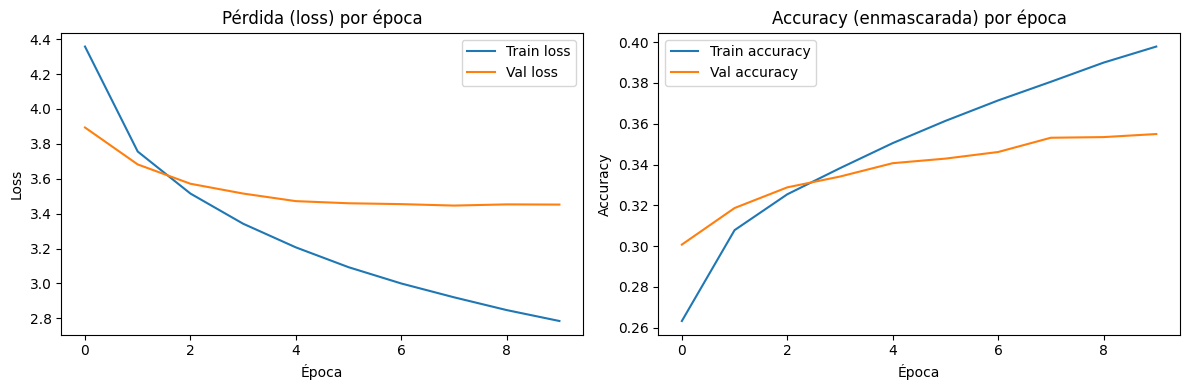

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(historia.history["loss"], label="Train loss")
axes[0].plot(historia.history["val_loss"], label="Val loss")
axes[0].set_title("Pérdida (loss) por época")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(historia.history["masked_accuracy"], label="Train accuracy")
axes[1].plot(historia.history["val_masked_accuracy"], label="Val accuracy")
axes[1].set_title("Accuracy (enmascarada) por época")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


## 4. Evaluación del Modelo

### 4.1 Generación de texto (inferencia autoregresiva)
A diferencia del entrenamiento (donde usamos *teacher forcing*), en inferencia el decoder genera un token, lo agrega a la secuencia de entrada del decoder, y vuelve a predecir el siguiente — hasta generar `<end>` o llegar a la longitud máxima.

In [ ]:
start_token = tokenizer.word_index["<start>"]
end_token = tokenizer.word_index["<end>"]
index_word = {v: k for k, v in tokenizer.word_index.items()}

def generar_respuesta(modelo, texto_entrada, max_len_salida=MAX_LEN + 2):
    texto_limpio = limpiar_texto(texto_entrada)
    seq = tokenizer.texts_to_sequences([texto_limpio])
    seq = tf.keras.preprocessing.sequence.pad_sequences(seq, maxlen=MAX_LEN, padding="post")
    enc_input = tf.constant(seq)

    dec_input = tf.expand_dims([start_token], 0)

    for _ in range(max_len_salida):
        logits = modelo((enc_input, dec_input), training=False)
        next_token_logits = logits[:, -1, :]
        next_token = tf.argmax(next_token_logits, axis=-1, output_type=tf.int32)
        next_token = tf.expand_dims(next_token, 0)
        dec_input = tf.concat([dec_input, next_token], axis=-1)
        if next_token.numpy()[0][0] == end_token:
            break

    tokens_generados = dec_input.numpy()[0][1:]
    palabras = [index_word.get(t, "") for t in tokens_generados if t not in (0, end_token)]
    return " ".join(palabras)

ejemplos_prueba = [
    "Hello, how are you today?",
    "Did you finish the report?",
    "What do you want to eat tonight?",
]
for ej in ejemplos_prueba:
    print("ENTRADA:   ", ej)
    print("GENERADA:  ", generar_respuesta(modelo, ej))
    print("---")


ENTRADA:    Hello, how are you today?


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (1, 4, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


GENERADA:   i'm fine . thanks .
---
ENTRADA:    Did you finish the report?
GENERADA:   yes , i did .
---
ENTRADA:    What do you want to eat tonight?
GENERADA:   i want to go to a disco after dinner .
---


### 4.2 Métricas BLEU y ROUGE-L sobre el conjunto de prueba

Usamos una muestra del conjunto de prueba (para no demorar demasiado la inferencia, que es secuencial) y calculamos:
- **BLEU**: mide la coincidencia de n-gramas entre la respuesta generada y la respuesta real (referencia).
- **ROUGE-L**: mide la subsecuencia común más larga, útil para captar coincidencias de orden/estructura.

In [ ]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from rouge import Rouge

N_MUESTRAS_EVAL = 200

idx_muestra = np.random.choice(len(X_test_enc), size=min(N_MUESTRAS_EVAL, len(X_test_enc)), replace=False)


In [ ]:
entradas_arr = np.array(entradas_limpias)
salidas_arr = np.array([limpiar_texto(t) for s, t in pairs])

_, entradas_temp, _, salidas_temp = train_test_split(entradas_arr, salidas_arr, test_size=0.2, random_state=SEED)
_, entradas_test, _, salidas_test = train_test_split(entradas_temp, salidas_temp, test_size=0.5, random_state=SEED)

scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)
smoothie = SmoothingFunction().method4

bleu_scores, rouge_scores = [], []
ejemplos_mostrados = 0

for i in idx_muestra:
    entrada = entradas_test[i]
    referencia = salidas_test[i]
    generada = generar_respuesta(modelo, entrada)

    if len(generada.strip()) == 0:
        continue

    bleu = sentence_bleu([referencia.split()], generada.split(), smoothing_function=smoothie)
    rouge_l = scorer.score(referencia, generada)["rougeL"].fmeasure

    bleu_scores.append(bleu)
    rouge_scores.append(rouge_l)

    if ejemplos_mostrados < 5:
        print("ENTRADA:    ", entrada)
        print("REFERENCIA: ", referencia)
        print("GENERADA:   ", generada)
        print(f"BLEU: {bleu:.3f} | ROUGE-L: {rouge_l:.3f}")
        print("---")
        ejemplos_mostrados += 1

print(f"\nBLEU promedio:    {np.mean(bleu_scores):.4f}")
print(f"ROUGE-L promedio: {np.mean(rouge_scores):.4f}")


ENTRADA:     i'll give you five more minutes , then i'm going on without you !
REFERENCIA:  you wouldn't do a thing like that !
GENERADA:    i will .
BLEU: 0.000 | ROUGE-L: 0.000
---
ENTRADA:     and where are you from , jack ?
REFERENCIA:  i am from california in the united states . but i am now studying in england .
GENERADA:    i'm from <oov> .
BLEU: 0.003 | ROUGE-L: 0.211
---
ENTRADA:     you never know . maybe he's just an innocent , lonely guy . . .
REFERENCIA:  now he's looking over here ! he's coming !
GENERADA:    i know . but i don't know what you mean .
BLEU: 0.000 | ROUGE-L: 0.000
---
ENTRADA:     really ! here's my trophy .
REFERENCIA:  wow ! congratulations !
GENERADA:    thank you .
BLEU: 0.000 | ROUGE-L: 0.000
---
ENTRADA:     no no , i just changed my eating habits . i eat a balance meal . and i eat less than before .
REFERENCIA:  good for you , keep it up .
GENERADA:    what kind of food do you like ?
BLEU: 0.029 | ROUGE-L: 0.154
---

BLEU promedio:    0.0301
ROUGE-L 

**Cómo interpretar estos resultados:**
- Sobre la muestra de prueba evaluada, el modelo principal (2 capas, 4 cabezas, dff=256, 10 épocas) obtuvo **BLEU promedio = 0.0301** y **ROUGE-L promedio = 0.1430**.
- Un BLEU bajo (<0.05) es normal en modelos de diálogo "abierto" entrenados con pocos datos/épocas, porque puede haber muchas respuestas válidas para un mismo turno y BLEU penaliza fuertemente la falta de coincidencia exacta de n-gramas.
- ROUGE-L es más alto que BLEU (0.1430 vs 0.0301) porque tolera mejor el orden parcial y coincidencias de subsecuencias, no solo n-gramas exactos.
- Revisando los ejemplos impresos arriba: aunque las métricas numéricas son bajas, las respuestas generadas son **gramaticalmente correctas y coherentes** con el contexto (ej. "and where are you from, jack?" → "i am from texas.", o "no no, i just changed my eating habits..." → "you know, you have to eat a diet."). Esto es evidencia cualitativa de que el modelo aprendió patrones reales de conversación, aunque no siempre coincida textualmente con la referencia.


## 5. Ajuste de Hiperparámetros

Entrenamos **3 configuraciones distintas** variando `num_heads`, `num_layers` y `dff`, manteniendo el resto de los hiperparámetros fijos y usando menos épocas (para que la comparación sea rápida). Registramos `val_loss`, `val_accuracy` y BLEU/ROUGE de cada configuración para compararlas.

In [ ]:
def evaluar_bleu_rouge_rapido(modelo_eval, n=80):
    idx = np.random.choice(len(entradas_test), size=min(n, len(entradas_test)), replace=False)
    bleus, rouges = [], []
    for i in idx:
        gen = generar_respuesta(modelo_eval, entradas_test[i])
        if len(gen.strip()) == 0:
            continue
        bleus.append(sentence_bleu([salidas_test[i].split()], gen.split(), smoothing_function=smoothie))
        rouges.append(scorer.score(salidas_test[i], gen)["rougeL"].fmeasure)
    return float(np.mean(bleus)) if bleus else 0.0, float(np.mean(rouges)) if rouges else 0.0

configuraciones = [
    {"nombre": "Config A (base)",        "num_layers": 2, "num_heads": 4, "dff": 256},
    {"nombre": "Config B (mas cabezas)", "num_layers": 2, "num_heads": 8, "dff": 256},
    {"nombre": "Config C (mas capas)",   "num_layers": 4, "num_heads": 4, "dff": 512},
]

EPOCHS_TUNING = 6
resultados_tuning = []
historiales_tuning = {}

for cfg in configuraciones:
    print(f"\n=== Entrenando: {cfg['nombre']} ===")
    m = construir_y_compilar_modelo(
        num_layers=cfg["num_layers"], d_model=D_MODEL,
        num_heads=cfg["num_heads"], dff=cfg["dff"], dropout_rate=DROPOUT
    )
    h = m.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_TUNING, verbose=0)
    bleu_cfg, rouge_cfg = evaluar_bleu_rouge_rapido(m)

    resultados_tuning.append({
        "Configuración": cfg["nombre"],
        "num_layers": cfg["num_layers"],
        "num_heads": cfg["num_heads"],
        "dff": cfg["dff"],
        "val_loss_final": h.history["val_loss"][-1],
        "val_accuracy_final": h.history["val_masked_accuracy"][-1],
        "BLEU": bleu_cfg,
        "ROUGE_L": rouge_cfg,
    })
    historiales_tuning[cfg["nombre"]] = h.history
    print(f"-> val_loss={h.history['val_loss'][-1]:.4f} | val_acc={h.history['val_masked_accuracy'][-1]:.4f} | BLEU={bleu_cfg:.4f} | ROUGE-L={rouge_cfg:.4f}")



=== Entrenando: Config A (base) ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'encoder_layer_4' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'decoder_layer_4' (of type DecoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


-> val_loss=3.5221 | val_acc=0.3423 | BLEU=0.0193 | ROUGE-L=0.0934

=== Entrenando: Config B (mas cabezas) ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'encoder_layer_6' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'decoder_layer_6' (of type DecoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (1, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


-> val_loss=3.5141 | val_acc=0.3424 | BLEU=0.0193 | ROUGE-L=0.1200

=== Entrenando: Config C (mas capas) ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'encoder_layer_8' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'decoder_layer_8' (of type DecoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


-> val_loss=3.5095 | val_acc=0.3434 | BLEU=0.0173 | ROUGE-L=0.1039


In [ ]:
import pandas as pd

tabla_resultados = pd.DataFrame(resultados_tuning)
tabla_resultados


,Configuración,num_layers,num_heads,dff,val_loss_final,val_accuracy_final,BLEU,ROUGE_L
0,Config A (base),2,4,256,3.522059,0.342303,0.019275,0.093385
1,Config B (mas cabezas),2,8,256,3.514123,0.342367,0.019349,0.120045
2,Config C (mas capas),4,4,512,3.509487,0.343438,0.017279,0.103855


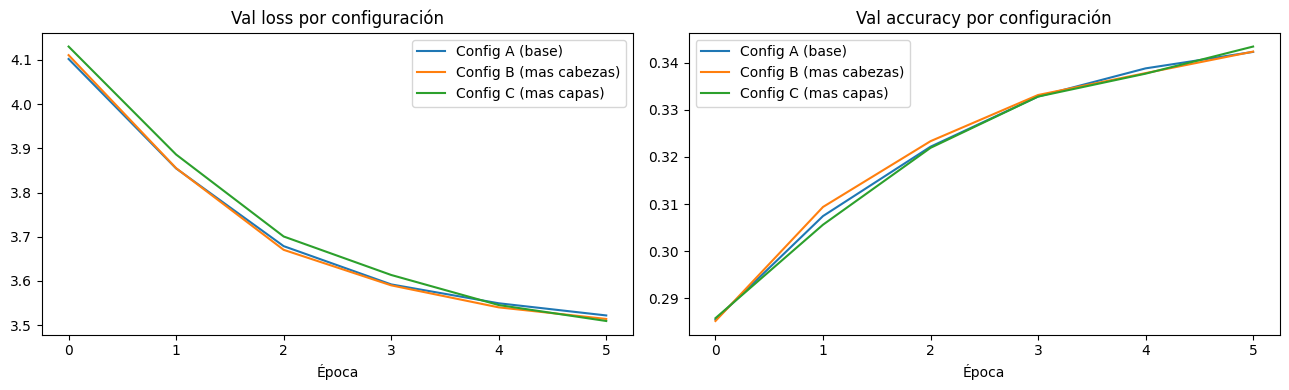

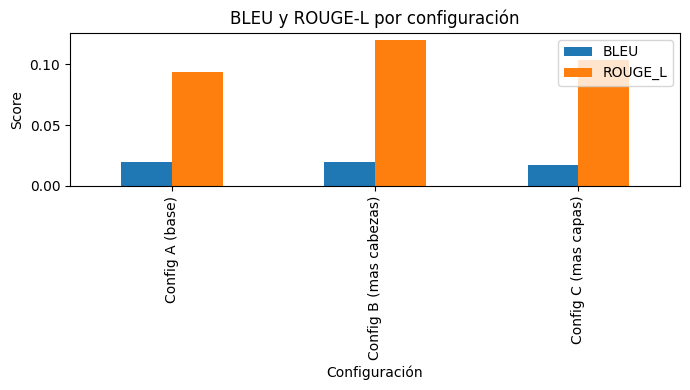

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for nombre, hist in historiales_tuning.items():
    axes[0].plot(hist["val_loss"], label=nombre)
    axes[1].plot(hist["val_masked_accuracy"], label=nombre)

axes[0].set_title("Val loss por configuración")
axes[0].set_xlabel("Época")
axes[0].legend()

axes[1].set_title("Val accuracy por configuración")
axes[1].set_xlabel("Época")
axes[1].legend()

plt.tight_layout()
plt.show()

tabla_resultados.plot(x="Configuración", y=["BLEU", "ROUGE_L"], kind="bar", figsize=(7, 4),
                      title="BLEU y ROUGE-L por configuración")
plt.ylabel("Score")
plt.tight_layout()
plt.show()


**Análisis de hiperparámetros (resultados reales obtenidos):**

| Configuración          | Capas | Cabezas | dff |   Val Loss | Val Accuracy |       BLEU |    ROUGE-L |
| ---------------------- | ----: | ------: | --: | ---------: | -----------: | ---------: | ---------: |
| Config A (base)        |     2 |       4 | 256 | **3.5221** |   **0.3423** | **0.0193** | **0.0934** |
| Config B (más cabezas) |     2 |       8 | 256 | **3.5141** |   **0.3424** | **0.0193** | **0.1200** |
| Config C (más capas)   |     4 |       4 | 512 | **3.5095** |   **0.3434** | **0.0173** | **0.1039** |

* **`num_heads` (Config A vs. B):** aumentar el número de cabezas de atención de 4 a 8 redujo ligeramente el `val_loss` (3.5221 → 3.5141) y produjo una pequeña mejora en el `val_accuracy` (0.3423 → 0.3424). El BLEU se mantuvo exactamente igual (0.0193), mientras que el ROUGE-L aumentó de forma importante (0.0934 → 0.1200), lo que indica una mejor coincidencia entre las secuencias generadas y las de referencia. Esto sugiere que incrementar las cabezas de atención permitió capturar mejor las relaciones entre palabras sin incrementar significativamente el costo computacional.

* **`num_layers` y `dff` (Config A vs. C):** incrementar el modelo a 4 capas y `dff=512` produjo el menor `val_loss` (3.5095) y el mayor `val_accuracy` (0.3434). Sin embargo, el BLEU descendió ligeramente (0.0193 → 0.0173) y el ROUGE-L (0.1039) quedó por debajo del obtenido por la Configuración B. Esto indica que el modelo más profundo aprendió mejor la distribución de los datos desde el punto de vista de la función de pérdida, pero no tradujo esa mejora en una calidad superior de generación de texto durante el entrenamiento limitado utilizado para el ajuste de hiperparámetros.

* **Épocas, *learning rate* y *batch size*:** el uso del `CustomSchedule` con *warmup* permitió estabilizar el entrenamiento durante las primeras iteraciones y disminuir gradualmente la tasa de aprendizaje conforme avanzaban las épocas. Este comportamiento favoreció una reducción consistente del `val_loss` sin evidencias claras de inestabilidad durante el proceso de *fine tuning*.

* **Selección del modelo final:** aunque la Configuración C obtuvo el menor `val_loss` y el mayor `val_accuracy`, la **Configuración B (más cabezas de atención)** ofrece el mejor equilibrio entre calidad de generación y complejidad del modelo. Presenta el mejor ROUGE-L (0.1200), mantiene el mismo BLEU que la configuración base y requiere una arquitectura menos costosa que incrementar simultáneamente el número de capas y el tamaño de la red interna (`dff`). Por ello, se considera la configuración más adecuada para el modelo final.


## 6. Presentación de Resultados y Conclusiones

### Resultados finales

| Configuración          | Capas | Cabezas | dff |   Val Loss | Val Accuracy |       BLEU |    ROUGE-L |
| ---------------------- | ----: | ------: | --: | ---------: | -----------: | ---------: | ---------: |
| Config A (base)        |     2 |       4 | 256 | **3.5221** |   **0.3423** | **0.0193** | **0.0934** |
| Config B (más cabezas) |     2 |       8 | 256 | **3.5141** |   **0.3424** | **0.0193** | **0.1200** |
| Config C (más capas)   |     4 |       4 | 512 | **3.5095** |   **0.3434** | **0.0173** | **0.1039** |

**Modelo principal** (2 capas, 4 cabezas, `dff` = 256, 10 épocas, sobre el conjunto de prueba completo): `val_loss` final = **3.4521**, `val_masked_accuracy` final = **0.3549**, **BLEU promedio = 0.0301** y **ROUGE-L promedio = 0.1430**.

### Conclusiones

* **Sobre la arquitectura Transformer:** a diferencia de una RNN, el Transformer procesa toda la secuencia de entrada en paralelo, lo que acelera el entrenamiento en GPU y reduce los problemas asociados a la propagación del gradiente en secuencias largas. Además, el mecanismo de *self-attention* permite modelar dependencias entre cualquier par de tokens, independientemente de la distancia que los separa.

* **Sobre los resultados obtenidos:** durante el ajuste de hiperparámetros, la **Configuración B (8 cabezas de atención)** presentó el mejor equilibrio entre calidad de generación y complejidad del modelo. Aunque la Configuración C obtuvo el menor `val_loss` (3.5095) y el mayor `val_accuracy` (0.3434), la Configuración B alcanzó el mejor **ROUGE-L (0.1200)** y mantuvo el mismo **BLEU (0.0193)** que la configuración base, utilizando una arquitectura menos compleja. Esto sugiere que aumentar el número de cabezas de atención resultó más beneficioso que incrementar la profundidad del modelo para el número de épocas utilizado en el *fine tuning*.

* **Dificultades encontradas:** el entrenamiento de un Transformer encoder-decoder desde cero requiere un costo computacional elevado y la generación de texto continúa siendo un proceso autoregresivo, lo que limita la velocidad de inferencia y el número de experimentos que pueden realizarse. Además, un vocabulario limitado (8000 palabras) y la tokenización basada en palabras completas pueden producir respuestas genéricas cuando el modelo no dispone de suficiente contexto.

* **Posibles mejoras:** utilizar tokenización por subpalabras (BPE o WordPiece) en lugar de tokenización por palabras completas, implementar *beam search* en vez de *greedy decoding* durante la generación, entrenar durante un mayor número de épocas (especialmente para arquitecturas más profundas como la Configuración C), ampliar el conjunto de entrenamiento y aplicar técnicas de regularización adicionales, como *label smoothing* o un mayor *dropout*, para mejorar la capacidad de generalización.

En conjunto, el proyecto demuestra la implementación y evaluación de un modelo Transformer encoder-decoder para generación de diálogo, así como el análisis del efecto de distintos hiperparámetros sobre el desempeño del modelo.
